In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

embeddings = np.load("../embeddings/052326_1936/embeddings_052326_1936.npy")
metadata = pd.read_parquet("../data/processed/master_metadata.parquet")

mask_valid = metadata["moa"].notna()
embeddings = embeddings[mask_valid.values]
metadata = metadata[mask_valid.values].copy()

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

emb_2d = reducer.fit_transform(embeddings)
assert len(embeddings) == len(metadata)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [2]:
print("MoA coverage:", metadata["moa"].notna().mean())
print(metadata["moa"].value_counts().head(10))

MoA coverage: 1.0
moa
control vehicle                             2719
calcium channel blocker                      288
CDK inhibitor                                225
HSP inhibitor                                212
SRC inhibitor                                180
sphingosine 1-phosphate receptor agonist     171
sodium channel blocker                       171
phosphodiesterase inhibitor                  150
HDAC inhibitor                               140
CDC inhibitor                                135
Name: count, dtype: int64


In [3]:
moa = metadata["moa"].copy()

# remove missing + convert to string
mask_valid = moa.notna()
moa = moa[mask_valid].astype(str)

embeddings = embeddings[mask_valid.values]
metadata = metadata[mask_valid.values].copy()
metadata["moa"] = moa

In [4]:
metadata.head()

,url_origlowzbf,url_orighighzbf,url_origbrightfield,plate,well,site,metadata_abspositionz,metadata_abstime,metadata_binningx,metadata_binningy,...,smiles,moa,dna_img_path,agp_img_path,mito_img_path,er_img_path,rna_img_path,is_control,compound_count,moa_count
0,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,1,0.134679,2020-11-05T19:55:20.94-05:00,2,2,...,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,adrenergic receptor agonist,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,0,45,45.0
1,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,2,0.134679,2020-11-05T19:55:22.673-05:00,2,2,...,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,adrenergic receptor agonist,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,0,45,45.0
2,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,3,0.134673,2020-11-05T19:55:24.217-05:00,2,2,...,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,adrenergic receptor agonist,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,0,45,45.0
3,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,4,0.134674,2020-11-05T19:55:25.747-05:00,2,2,...,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,adrenergic receptor agonist,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,0,45,45.0
4,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,5,0.134681,2020-11-05T19:55:27.243-05:00,2,2,...,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,adrenergic receptor agonist,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,0,45,45.0


# Model metrics over time

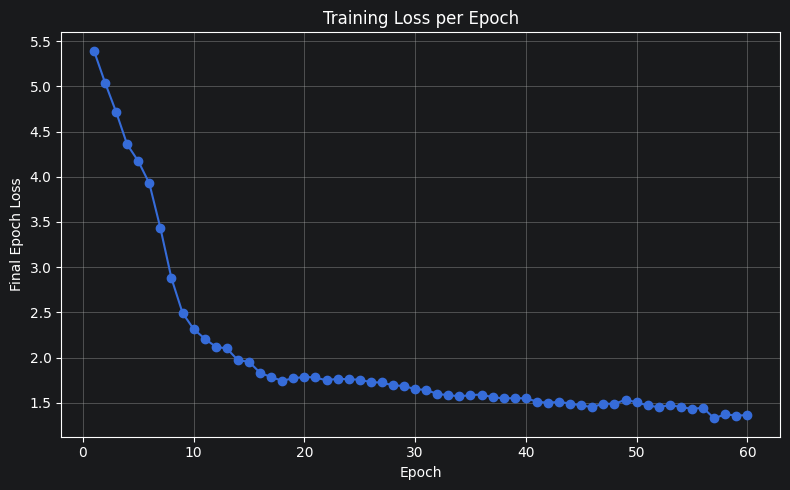

In [5]:
import re

log_file = "../analysis/outputs/dino_7001416.out"

epochs = []
losses = []

# Matches lines like:
# Epoch 1/60 | Loss: 3.3637 | Total Time: 4.40 min
pattern = re.compile(
    r"Epoch\s+(\d+)/(\d+)\s+\|\s+Loss:\s+([0-9.]+)"
)

with open(log_file, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            epoch_num = int(match.group(1))
            loss = float(match.group(3))

            epochs.append(epoch_num)
            losses.append(loss)

# Plot loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Final Epoch Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)

plt.tight_layout()
plt.show()

# Visualizations

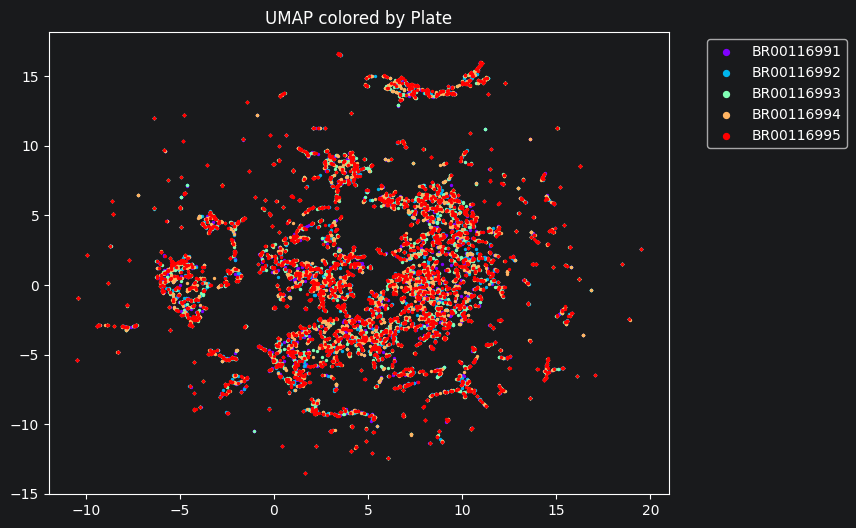

In [6]:
plates = metadata["plate"].astype("category")
labels = plates.cat.codes
categories = plates.cat.categories
cmap = plt.get_cmap("rainbow", len(categories))

plt.figure(figsize=(8,6))

for i, cat in enumerate(categories):
    mask = (labels == i)
    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=2,
        color=cmap(i),
        label=cat
    )

plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("UMAP colored by Plate")
plt.show()

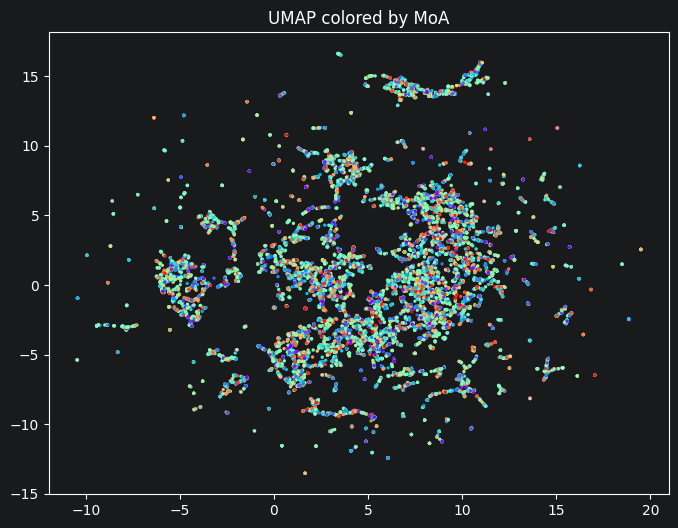

In [7]:
labels = metadata["moa"].astype("category").cat.codes

plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels, s=2, cmap="rainbow")
plt.title("UMAP colored by MoA")
plt.show()

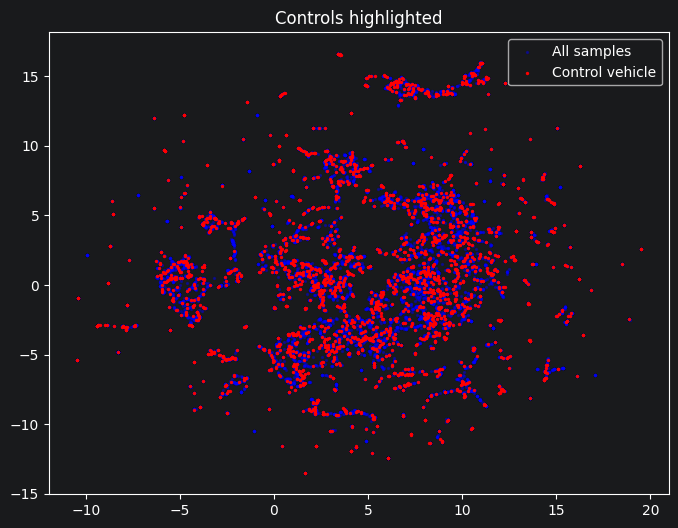

In [8]:
control_mask = metadata["moa"] == "control vehicle"

plt.figure(figsize=(8,6))

# background (all samples)
plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    s=2,
    alpha=0.35,
    color="blue",
    label="All samples"
)

# controls on top
plt.scatter(
    emb_2d[control_mask,0],
    emb_2d[control_mask,1],
    s=2,
    color="red",
    label="Control vehicle"
)

plt.legend()
plt.title("Controls highlighted")
plt.show()

In [9]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=6, metric="cosine").fit(embeddings)
distances, indices = nbrs.kneighbors(embeddings)

# check neighbor compound match rate
matches = []
for i in range(len(indices)):
    base = metadata.iloc[i]["moa"]
    neigh = metadata.iloc[indices[i][1:]]["moa"]
    matches.append((neigh == base).mean())

print("Avg neighbor MoA match:", np.mean(matches))
baseline = (metadata["moa"].value_counts(normalize=True) ** 2).sum()
print("Baseline chance match:", baseline)

Avg neighbor MoA match: 0.12300603543383735
Baseline chance match: 0.035824639518172385


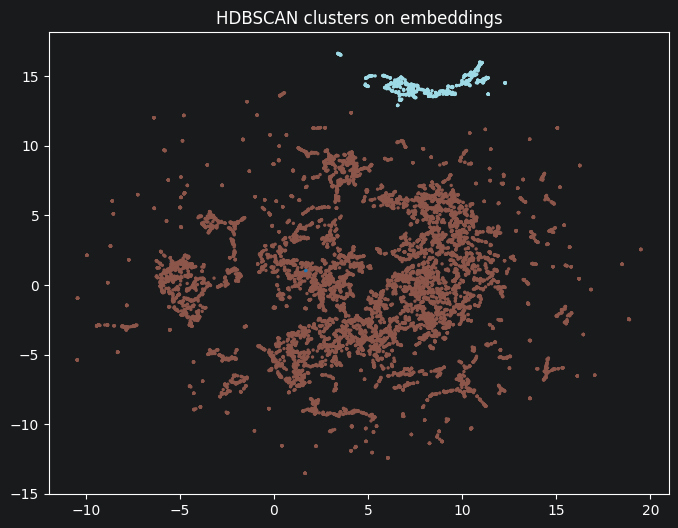

In [10]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
clusters = clusterer.fit_predict(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=clusters, s=2, cmap="tab20")
plt.title("HDBSCAN clusters on embeddings")
plt.show()

In [11]:
df = metadata.copy()
df["cluster"] = clusters

cluster_purity = df.groupby("cluster")["moa"].apply(
    lambda x: x.value_counts(normalize=True).max()
)

print("Mean cluster purity:", cluster_purity.mean())

Mean cluster purity: 0.1650239776362867


In [12]:
metadata["cluster"] = clusters

summary = metadata.groupby("cluster")["moa"].value_counts().head(20)
print(summary)

cluster  moa                                       
-1       CDC inhibitor                                    1
         GABA receptor antagonist                         1
         IGF-1 inhibitor                                  1
         aldehyde dehydrogenase inhibitor                 1
         aldose reductase inhibitor                       1
         bromodomain inhibitor                            1
         caspase inhibitor                                1
         histone lysine methyltransferase inhibitor       1
 0       control vehicle                               2554
         calcium channel blocker                        281
         CDK inhibitor                                  212
         HSP inhibitor                                  198
         SRC inhibitor                                  168
         sphingosine 1-phosphate receptor agonist       163
         sodium channel blocker                         162
         phosphodiesterase inhibitor            

# Umap excluding controls

In [13]:
mask = metadata["moa"] != "control vehicle"

emb_2d_noctrl = emb_2d[mask]
moa_noctrl = metadata.loc[mask, "moa"]

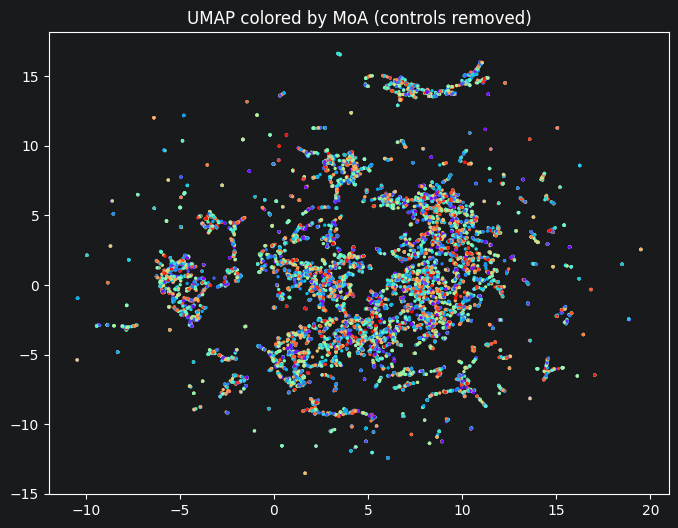

In [14]:
import matplotlib.pyplot as plt

labels = moa_noctrl.astype("category").cat.codes

plt.figure(figsize=(8,6))
plt.scatter(
    emb_2d_noctrl[:,0],
    emb_2d_noctrl[:,1],
    c=labels,
    s=2,
    cmap="rainbow"
)
plt.title("UMAP colored by MoA (controls removed)")
plt.show()

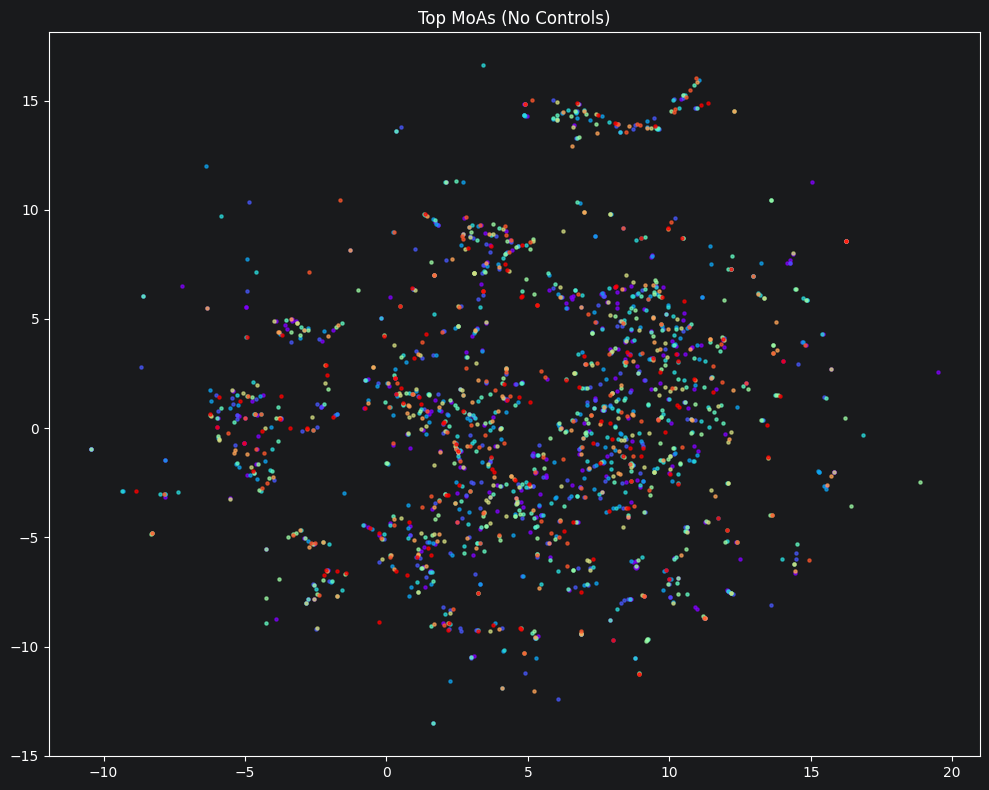

In [42]:
top_moas = (
    moa_noctrl.value_counts()
    .head(10)
    .index
)

cmap = plt.get_cmap("rainbow", len(top_moas))

plt.figure(figsize=(10,8))

for i, moa in enumerate(top_moas):

    moa_mask = moa_noctrl == moa

    plt.scatter(
        emb_2d_noctrl[moa_mask, 0],
        emb_2d_noctrl[moa_mask, 1],
        s=5,
        alpha=0.7,
        color=cmap(i)#,
        #label=moa
    )

#plt.legend(markerscale=4, bbox_to_anchor=(1.05, 1))
plt.title("Top MoAs (No Controls)")
plt.tight_layout()
plt.show()

# Replicate matching

In [15]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

nbrs = NearestNeighbors(n_neighbors=6, metric="cosine").fit(embeddings)
_, indices = nbrs.kneighbors(embeddings)

matches = []

for i in range(len(indices)):
    base = metadata.iloc[i]["broad_sample"]
    neigh = metadata.iloc[indices[i][1:]]["broad_sample"]
    matches.append((neigh == base).mean())

print("Replicate match @5:", np.mean(matches))

Replicate match @5: 0.12137062755532481


In [16]:
matches = []

for i in range(len(indices)):
    base = metadata.iloc[i]["plate"]
    neigh = metadata.iloc[indices[i][1:]]["plate"]
    matches.append((neigh == base).mean())

print("Plate match @5:", np.mean(matches))

Plate match @5: 0.2732688688428841


In [17]:
ctrl = (
    (metadata["moa"] == "control vehicle") |
    (metadata["pert_iname"] == "DMSO") |
    (metadata["pert_type"] == "control")
)

ctrl_centroid = embeddings[ctrl].mean(axis=0)
treat_centroid = embeddings[~ctrl].mean(axis=0)

from numpy.linalg import norm

cos_sim = np.dot(ctrl_centroid, treat_centroid) / (
    norm(ctrl_centroid) * norm(treat_centroid)
)

print("Control vs treated cosine similarity:", cos_sim)

Control vs treated cosine similarity: 0.9998757


# Probes

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Batch / plate prediction probe
X = embeddings
y = metadata["plate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(
    max_iter=2000,
    n_jobs=-1
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Plate/batch prediction accuracy:", acc)
print("Chance baseline approx:", 1 / len(np.unique(y)))

Plate/batch prediction accuracy: 0.2099286177806619
Chance baseline approx: 0.2


In [19]:
# MoA prediction probe (global signal check)
y = metadata["moa"]

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=3000, n_jobs=-1)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
acc = accuracy_score(y_test, pred)

print("MoA prediction accuracy:", acc)
print("Chance baseline:", 1 / len(np.unique(y)))

MoA prediction accuracy: 0.1765087605451006
Chance baseline: 0.00510204081632653


In [20]:
# Within-plate vs cross-plate MoA test
plates = metadata["plate"].unique()

within_scores = []
cross_scores = []

for i, plate in enumerate(plates):
    print(f"Plate {plate} of {len(plates)}")
    plate_mask = metadata["plate"] == plate
    other_mask = ~plate_mask

    # --- within-plate ---
    X = embeddings[plate_mask.values]
    y = metadata["moa"][plate_mask.values]

    if len(np.unique(y)) < 2:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = LogisticRegression(max_iter=3000, solver="saga")
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    within_scores.append(accuracy_score(y_test, pred))

    # --- cross-plate ---
    X_train = embeddings[other_mask.values]
    y_train = metadata["moa"][other_mask.values]

    X_test = embeddings[plate_mask.values]
    y_test = metadata["moa"][plate_mask.values]

    if len(np.unique(y_train)) < 2:
        continue

    clf = LogisticRegression(max_iter=3000, solver="saga")
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    cross_scores.append(accuracy_score(y_test, pred))

print("\nWithin-plate MoA accuracy:", np.mean(within_scores))
print("Cross-plate MoA accuracy:", np.mean(cross_scores))

Within-plate MoA accuracy: 0.17706036866906544
Cross-plate MoA accuracy: 0.17701411563001726


In [21]:
within_scores = []

for plate in plates:
    mask = metadata["plate"] == plate

    X_plate = embeddings[mask]
    y_plate = metadata["moa"][mask]

    if len(np.unique(y_plate)) < 2:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_plate, y_plate, test_size=0.2, random_state=42, stratify=y_plate
    )

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)

    within_scores.append(acc)

print("Within-plate MoA accuracy:", np.mean(within_scores))

Within-plate MoA accuracy: 0.17706036866906544


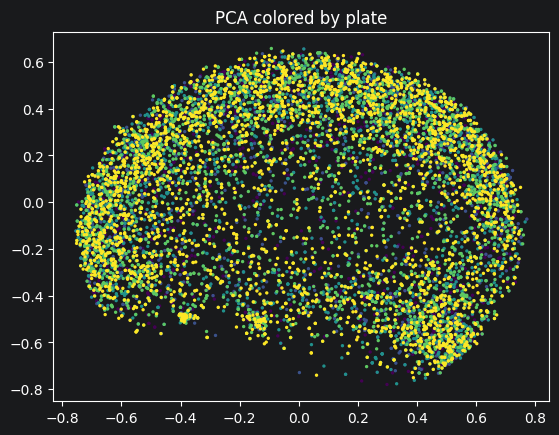

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
Z = pca.fit_transform(embeddings)

plt.scatter(Z[:,0], Z[:,1], c=metadata["plate"].astype("category").cat.codes, s=2)
plt.title("PCA colored by plate")
plt.show()

# Tile vs well level embeddings

In [24]:
# -----------------------------
# TILE-LEVEL
# -----------------------------
tile_embeddings = embeddings.copy()

tile_metadata = metadata.copy().reset_index(drop=True)

# -----------------------------
# WELL-LEVEL AGGREGATION
# -----------------------------
tile_metadata["well_key"] = (
    tile_metadata["plate"].astype(str)
    + "__"
    + tile_metadata["well"].astype(str)
)

well_df = tile_metadata.copy()
well_df["embedding_idx"] = np.arange(len(tile_embeddings))

grouped = well_df.groupby("well_key")

well_embeddings = []
well_moa = []

for key, group in grouped:
    idx = group["embedding_idx"].values

    emb = tile_embeddings[idx].mean(axis=0)

    moa = group["moa"].mode().iloc[0]

    well_embeddings.append(emb)
    well_moa.append(moa)

well_embeddings = np.stack(well_embeddings)
well_moa = np.array(well_moa)

print("Tile embeddings:", tile_embeddings.shape)
print("Well embeddings:", well_embeddings.shape)

# -----------------------------
# Neighbor MoA metric
# -----------------------------
def neighbor_moa_match(X, labels, k=5):
    nbrs = NearestNeighbors(
        n_neighbors=k+1,
        metric="cosine"
    ).fit(X)

    distances, indices = nbrs.kneighbors(X)

    matches = []

    for i in range(len(X)):
        neigh_labels = labels[indices[i][1:]]
        matches.append(np.mean(neigh_labels == labels[i]))

    return np.mean(matches)

tile_score = neighbor_moa_match(
    tile_embeddings,
    tile_metadata["moa"].values
)

well_score = neighbor_moa_match(
    well_embeddings,
    well_moa
)

print(f"Tile neighbor MoA match: {tile_score:.4f}")
print(f"Well neighbor MoA match: {well_score:.4f}")

Tile embeddings: (15409, 384)
Well embeddings: (1717, 384)
Tile neighbor MoA match: 0.1230
Well neighbor MoA match: 0.0381


Top 10 explained variance ratios:
[0.31464514 0.2259181  0.15553191 0.08302373 0.06545897 0.0462816
 0.02492131 0.02256962 0.01789802 0.00881191]

Top 10 singular values:
[54.053493 45.802456 38.00345  27.766066 24.654593 20.730865 15.212435
 14.476895 12.891867  9.045825]


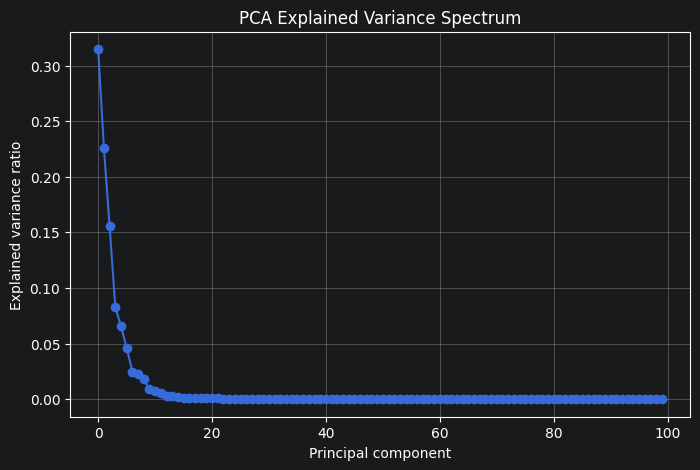

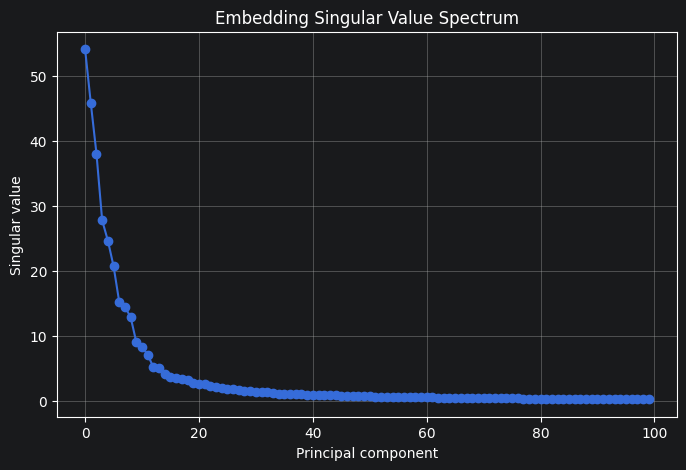


Effective rank (>1% variance): 9


In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------------
# PCA
# -----------------------------------
pca = PCA(n_components=min(100, embeddings.shape[1]))

pca.fit(embeddings)

explained = pca.explained_variance_ratio_
singular_vals = pca.singular_values_

print("Top 10 explained variance ratios:")
print(explained[:10])

print("\nTop 10 singular values:")
print(singular_vals[:10])

# -----------------------------------
# Explained variance plot
# -----------------------------------
plt.figure(figsize=(8,5))
plt.plot(explained, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Explained Variance Spectrum")
plt.grid(True)
plt.show()

# -----------------------------------
# Singular values plot
# -----------------------------------
plt.figure(figsize=(8,5))
plt.plot(singular_vals, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Singular value")
plt.title("Embedding Singular Value Spectrum")
plt.grid(True)
plt.show()

# -----------------------------------
# Effective rank estimate
# -----------------------------------
threshold = 0.01

effective_rank = np.sum(explained > threshold)

print(f"\nEffective rank (>1% variance): {effective_rank}")

In [27]:
from sklearn.metrics.pairwise import cosine_distances

control_emb = embeddings[control_mask.values]
treated_emb = embeddings[treated_mask.values]

control_dist = cosine_distances(control_emb)
treated_dist = cosine_distances(treated_emb)

print("Mean control cosine distance:",
      control_dist.mean())

print("Mean treated cosine distance:",
      treated_dist.mean())

Mean control cosine distance: 0.60833305
Mean treated cosine distance: 0.6013756
